# Results Dashboard

Visualizes experiment results from the centralized `results/experiment_results.csv`.

This CSV is automatically populated by `graphium-train` after each run.
Each row = one training run with metadata and all test metrics.

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_CSV = Path('../results/experiment_results.csv')
df = pd.read_csv(RESULTS_CSV)
print(f"Loaded {len(df)} rows from {RESULTS_CSV}")

# Derive a human-readable model_name from (model, hidden_dim, gnn_depth)
def infer_model_name(row):
    m = str(row.get('model', ''))
    dim = row.get('hidden_dim', 0)
    depth = row.get('gnn_depth', 0)
    if m == 'pyg:pairformer':
        if dim == 384:
            return 'pairformer_boltz'
        return 'pairformer'
    if m == 'pyg:gps':
        if dim == 1536 and depth == 12:
            return 'gpspp_800M'
        return f'gpspp_{int(dim)}d{int(depth)}'
    return 'unknown'

df['model_name'] = df.apply(infer_model_name, axis=1)

# === Filter: select which model(s) to show ===
MODELS_TO_SHOW = ['gpspp_800M', 'pairformer_boltz']
df = df[df['model_name'].isin(MODELS_TO_SHOW)].reset_index(drop=True)
print(f"After filtering to {MODELS_TO_SHOW}: {len(df)} rows")
print(f"  model_name counts: {df['model_name'].value_counts().to_dict()}")

Loaded 594 rows from ../results/experiment_results.csv
After filtering to ['gpspp_800M', 'pairformer_boltz']: 297 rows
  model_name counts: {'gpspp_800M': 274, 'pairformer_boltz': 23}


## 1. Overview: runs by model and task

In [2]:
print("Runs by model:")
print(df['model_name'].value_counts().to_string())
print()
print("Runs by task:")
print(df['task'].value_counts().to_string())
print()
df['is_finetuning'] = df['is_finetuning'].fillna(False).astype(bool)
print(f"Finetuned: {df['is_finetuning'].sum()} / Scratch: {(~df['is_finetuning']).sum()}")

Runs by model:
model_name
gpspp_800M          274
pairformer_boltz     23

Runs by task:
task
multitask                         36
solubility_aqsoldb                26
caco2_wang                        26
vdss_lombardo                     12
half_life_obach                   12
ppbr_az                           12
lipophilicity_astrazeneca         12
clearance_hepatocyte_az           12
clearance_microsome_az            12
hia_hou                           11
pgp_broccatelli                   11
bbb_martins                       11
bioavailability_ma                11
cyp2d6_veith                      11
cyp3a4_veith                      10
cyp3a4_substrate_carbonmangels     9
cyp2d6_substrate_carbonmangels     9
cyp2c9_substrate_carbonmangels     9
cyp2c9_veith                       9
ld50_zhu                           9
herg                               9
ames                               9
dili                               9

Finetuned: 229 / Scratch: 68


## 2. Extract primary metric per task

Each ADMET task has a primary metric. We extract the test metric column for each task.

In [3]:
# TDC ADMET primary metrics (ordered by category as in the TDC paper)
# https://tdcommons.ai/benchmark/admet_group/overview/

# Canonical task ordering: Absorption -> Distribution -> Metabolism -> Excretion -> Toxicity
ADMET_TASK_ORDER = [
    # Absorption
    'caco2_wang', 'hia_hou', 'pgp_broccatelli', 'bioavailability_ma',
    'lipophilicity_astrazeneca', 'solubility_aqsoldb',
    # Distribution
    'bbb_martins', 'ppbr_az', 'vdss_lombardo',
    # Metabolism
    'cyp2d6_veith', 'cyp3a4_veith', 'cyp2c9_veith',
    'cyp2c9_substrate_carbonmangels', 'cyp2d6_substrate_carbonmangels', 'cyp3a4_substrate_carbonmangels',
    # Excretion
    'half_life_obach', 'clearance_hepatocyte_az', 'clearance_microsome_az',
    # Toxicity
    'ld50_zhu', 'herg', 'ames', 'dili',
]

TASK_CATEGORY = {}
for t in ADMET_TASK_ORDER[:6]:   TASK_CATEGORY[t] = 'Absorption'
for t in ADMET_TASK_ORDER[6:9]:  TASK_CATEGORY[t] = 'Distribution'
for t in ADMET_TASK_ORDER[9:15]: TASK_CATEGORY[t] = 'Metabolism'
for t in ADMET_TASK_ORDER[15:18]: TASK_CATEGORY[t] = 'Excretion'
for t in ADMET_TASK_ORDER[18:]:  TASK_CATEGORY[t] = 'Toxicity'

TASK_METRICS = {
    'caco2_wang': ('mae', 'lower'),
    'hia_hou': ('auroc', 'higher'),
    'pgp_broccatelli': ('auroc', 'higher'),
    'bioavailability_ma': ('auroc', 'higher'),
    'lipophilicity_astrazeneca': ('mae', 'lower'),
    'solubility_aqsoldb': ('mae', 'lower'),
    'bbb_martins': ('auroc', 'higher'),
    'ppbr_az': ('mae', 'lower'),
    'vdss_lombardo': ('spearman', 'higher'),
    'cyp2d6_veith': ('auprc', 'higher'),
    'cyp3a4_veith': ('auprc', 'higher'),
    'cyp2c9_veith': ('auprc', 'higher'),
    'cyp2c9_substrate_carbonmangels': ('auprc', 'higher'),
    'cyp2d6_substrate_carbonmangels': ('auprc', 'higher'),
    'cyp3a4_substrate_carbonmangels': ('auroc', 'higher'),
    'half_life_obach': ('spearman', 'higher'),
    'clearance_hepatocyte_az': ('spearman', 'higher'),
    'clearance_microsome_az': ('spearman', 'higher'),
    'ld50_zhu': ('mae', 'lower'),
    'herg': ('auroc', 'higher'),
    'ames': ('auroc', 'higher'),
    'dili': ('auroc', 'higher'),
}

# TDC Leaderboard SOTA (rank #1) results: (mean, std, method_name)
# Source: https://tdcommons.ai/benchmark/admet_group/
TDC_SOTA = {
    'caco2_wang':                       (0.256, 0.006, 'CaliciBoost'),
    'hia_hou':                          (0.993, 0.005, 'MiniMol'),
    'pgp_broccatelli':                  (0.938, 0.002, 'MapLight + GNN'),
    'bioavailability_ma':               (0.942, 0.002, 'MiniMol'),
    'lipophilicity_astrazeneca':        (0.456, 0.008, 'MiniMol'),
    'solubility_aqsoldb':               (0.741, 0.013, 'MiniMol'),
    'bbb_martins':                      (0.924, 0.003, 'MiniMol'),
    'ppbr_az':                          (7.440, 0.024, 'Gradient Boost'),
    'vdss_lombardo':                    (0.713, 0.007, 'MapLight + GNN'),
    'cyp2d6_veith':                     (0.790, 0.001, 'MapLight + GNN'),
    'cyp3a4_veith':                     (0.916, 0.000, 'MapLight + GNN'),
    'cyp2c9_veith':                     (0.859, 0.001, 'MapLight + GNN'),
    'cyp2c9_substrate_carbonmangels':   (0.474, 0.025, 'MiniMol'),
    'cyp2d6_substrate_carbonmangels':   (0.736, 0.024, 'ContextPred'),
    'cyp3a4_substrate_carbonmangels':   (0.667, 0.019, 'CFA'),
    'half_life_obach':                  (0.576, 0.025, 'CFA'),
    'clearance_hepatocyte_az':          (0.536, 0.020, 'CFA'),
    'clearance_microsome_az':           (0.630, 0.010, 'MapLight + GNN'),
    'ld50_zhu':                         (0.552, 0.009, 'BaseBoosting'),
    'herg':                             (0.880, 0.002, 'MapLight + GNN'),
    'ames':                             (0.871, 0.002, 'ZairaChem'),
    'dili':                             (0.956, 0.006, 'MiniMol'),
}

def find_metric_column(df, task, metric_name):
    """Find the test metric column for a given task."""
    candidates = [c for c in df.columns if task in c.lower() and metric_name in c.lower() and 'test' in c.lower()]
    if candidates:
        return candidates[0]
    candidates = [c for c in df.columns if 'loss' in c.lower() and 'test' in c.lower()]
    return candidates[0] if candidates else None

def extract_primary_metric(row):
    """Extract the primary metric value for the task in this row."""
    task = row.get('task', '')
    if task not in TASK_METRICS:
        return np.nan
    metric_name, _ = TASK_METRICS[task]
    col = find_metric_column(df, task, metric_name)
    if col is None:
        return np.nan
    return row.get(col, np.nan)

df['primary_metric'] = df.apply(extract_primary_metric, axis=1)
df['metric_direction'] = df['task'].map(lambda t: TASK_METRICS.get(t, (None, None))[1])
df['metric_name'] = df['task'].map(lambda t: TASK_METRICS.get(t, (None, None))[0])
df['category'] = df['task'].map(TASK_CATEGORY)

print(f"Tasks with extracted metrics: {df['primary_metric'].notna().sum()} / {len(df)}")

# Report rows that failed metric extraction
_failed = df[df['primary_metric'].isna()]
if len(_failed) > 0:
    print(f"\nFailed metric extraction ({len(_failed)} rows):")
    for task, count in _failed['task'].value_counts().items():
        if task not in TASK_METRICS:
            reason = "task not in TASK_METRICS (not an ADMET single-task)"
        else:
            metric_name, _ = TASK_METRICS[task]
            col = find_metric_column(df, task, metric_name)
            reason = f"metric column not found for '{metric_name}'" if col is None else "metric value is NaN"
        print(f"  - task='{task}' × {count} rows  ({reason})")

Tasks with extracted metrics: 261 / 297

Failed metric extraction (36 rows):
  - task='multitask' × 36 rows  (task not in TASK_METRICS (not an ADMET single-task))


## 3. Dataset type ablation

Compare downstream ADMET performance across pre-training datasets.

In [4]:
def parse_pretrain_dataset(pretrain_model_path):
    """Infer the pre-training dataset from the checkpoint path."""
    s = str(pretrain_model_path).lower()
    if s == 'scratch' or s == 'nan':
        return 'scratch'
    for name, patterns in [
        # Three-component patterns MUST come before two-component ones
        ('toymix_rxrx3_dti',   ['toymix_rxrx3_dti', 'toymix-rxrx3-dti', 'toymixrxrx3dti']),
        ('largemix_rxrx3_dti', ['largemix_rxrx3_dti', 'largemix-rxrx3-dti', 'largemixrxrx3dti']),
        # Two-component patterns
        ('largemix_rxrx3', ['largemix_rxrx3', 'largemixrxrx3', 'largemix-rxrx3']),
        ('largemix_dti',   ['largemix_dti', 'largemixdti', 'largemix-dti']),
        ('toymix_rxrx3',   ['toymix_rxrx3', 'toymixrxrx3', 'toymix-rxrx3']),
        ('toymix_dti',     ['toymix_dti', 'toymixdti', 'toymix-dti']),
        ('rxrx3_dti',      ['rxrx3_dti', 'rxrx3-dti', 'rxrx3dti', 'dti_rxrx3', 'dti-rxrx3', 'dtirxrx3']),
        # Single-component patterns
        ('largemix',       ['largemix', 'large-dataset']),
        ('toymix',         ['toymix', 'small-dataset']),
        ('rxrx3',          ['rxrx3']),
        ('dti',            ['/dti/', '/dti-']),
    ]:
        if any(p in s for p in patterns):
            return name
    return 'unknown'

def parse_data_fraction(row):
    """Extract data fraction from W&B tags, or from known checkpoint mapping."""
    tags = str(row.get('wandb_tags', ''))
    match = re.search(r'frac_(\d+\.?\d*)', tags)
    if match:
        return float(match.group(1))
    KNOWN_FRACS = {
        '2026-03-18_14-53-57': 0.5,  # toymix 50%
    }
    pt = str(row.get('pretrain_dataset', ''))
    for ts, frac in KNOWN_FRACS.items():
        if ts in pt:
            return frac
    return 1.0

def build_method_label(row):
    """Create a human-readable method label for the results table."""
    ft = row.get('is_finetuning', False)
    pt = row.get('pretrain_type', 'scratch')
    frac = row.get('data_fraction', 1.0)
    frac_str = f' {frac:.0%}' if frac < 1.0 else ''
    if not ft and pt == 'scratch':
        return 'Scratch'
    if ft:
        return f'FT ({pt}{frac_str})'
    return pt

def count_best_among_methods(task_method_pivot, methods, task_metrics):
    """Count how many tasks each method is the best performer (among the given methods)."""
    from collections import Counter
    wins = Counter()
    n_tasks = 0
    for task in task_method_pivot.index:
        if task not in task_metrics:
            continue
        direction = task_metrics[task][1]
        row = task_method_pivot.loc[task, [m for m in methods if m in task_method_pivot.columns]].dropna()
        if len(row) == 0:
            continue
        n_tasks += 1
        best = row.idxmin() if direction == 'lower' else row.idxmax()
        wins[best] += 1
    return {m: (wins.get(m, 0), n_tasks) for m in methods if m in task_method_pivot.columns}

df['pretrain_type'] = df['pretrain_dataset'].apply(parse_pretrain_dataset)
df['primary_metric'] = pd.to_numeric(df['primary_metric'], errors='coerce')
df['data_fraction'] = df.apply(parse_data_fraction, axis=1)
df['method'] = df.apply(build_method_label, axis=1)

# Filter to ADMET tasks only, excluding unknown pretrain datasets
admet_df = df[df['task'].isin(TASK_METRICS.keys())].copy()
admet_df = admet_df[admet_df['pretrain_type'] != 'unknown']

# Keep only the most recent run per (task, model_name, method) triple
admet_df['timestamp'] = pd.to_datetime(admet_df['timestamp'], errors='coerce')
admet_df = admet_df.sort_values('timestamp').drop_duplicates(
    subset=['task', 'model_name', 'method'], keep='last'
).reset_index(drop=True)
print(f"After dedup to latest run per (task, model_name, method): {len(admet_df)} rows")
print(f"Models in data: {admet_df['model_name'].value_counts().to_dict()}")

# --- Compute global best (across all architectures) per task ---
global_best_per_task = {}  # task -> (model_name, method, value)
if len(admet_df) > 0 and admet_df['primary_metric'].notna().any():
    for task in ADMET_TASK_ORDER:
        task_rows = admet_df[admet_df['task'] == task].dropna(subset=['primary_metric'])
        if len(task_rows) == 0:
            continue
        direction = TASK_METRICS.get(task, (None, 'higher'))[1]
        if direction == 'lower':
            best_row = task_rows.loc[task_rows['primary_metric'].idxmin()]
        else:
            best_row = task_rows.loc[task_rows['primary_metric'].idxmax()]
        global_best_per_task[task] = (best_row['model_name'], best_row['method'])

# --- Display one table per architecture ---
if len(admet_df) > 0 and admet_df['primary_metric'].notna().any():
    for model_name in MODELS_TO_SHOW:
        model_df = admet_df[admet_df['model_name'] == model_name]
        if len(model_df) == 0 or model_df['primary_metric'].isna().all():
            print(f"\n--- {model_name}: no ADMET results yet ---")
            continue

        pivot = model_df.pivot_table(
            index='task', columns='method', values='primary_metric', aggfunc='mean'
        )

        row_order = [t for t in ADMET_TASK_ORDER if t in pivot.index]
        pivot = pivot.loc[row_order]

        method_order = ['Scratch'] + sorted([c for c in pivot.columns if c.startswith('FT')])
        method_order += [c for c in pivot.columns if c not in method_order]
        pivot = pivot[[c for c in method_order if c in pivot.columns]]

        row_labels = []
        for task in pivot.index:
            metric_name, direction = TASK_METRICS.get(task, ('?', 'higher'))
            arrow = '\u2191' if direction == 'higher' else '\u2193'
            row_labels.append(f'{task}  ({metric_name} {arrow})')

        # Find best column per row within this architecture
        arch_best_per_row = {}
        for task in pivot.index:
            direction = TASK_METRICS.get(task, (None, 'higher'))[1]
            row_vals = pivot.loc[task].dropna()
            if len(row_vals) > 0:
                best_col = row_vals.idxmin() if direction == 'lower' else row_vals.idxmax()
                arch_best_per_row[task] = best_col

        numeric_pivot = pivot.copy()

        # Insert TDC SOTA column on the left
        sota_col = []
        for task in pivot.index:
            if task in TDC_SOTA:
                mean, std, _ = TDC_SOTA[task]
                sota_col.append(f'{mean:.3f} \u00b1 {std:.3f}')
            else:
                sota_col.append('')
        pivot.insert(0, 'TDC SOTA', sota_col)

        # Compute category boundaries
        category_boundaries = set()
        prev_cat = None
        for i, task in enumerate(pivot.index):
            cat = TASK_CATEGORY.get(task)
            if prev_cat is not None and cat != prev_cat:
                category_boundaries.add(i)
            prev_cat = cat

        display_pivot = pivot.copy()
        display_pivot.index = row_labels

        # Styling: bold = best within arch, blue+underline = best across all archs
        def make_highlight(arch_best, global_best, cur_model, dp, pv):
            def highlight(row):
                task = pv.index[dp.index.get_loc(row.name)]
                styles = [''] * len(row)
                # Architecture best: bold
                if task in arch_best:
                    j = list(dp.columns).index(arch_best[task])
                    styles[j] = 'font-weight: bold'
                # Global best: blue + underline (may overlap with bold)
                if task in global_best:
                    g_model, g_method = global_best[task]
                    if g_model == cur_model and g_method in dp.columns:
                        k = list(dp.columns).index(g_method)
                        styles[k] = 'font-weight: bold; color: #1a5fb4; text-decoration: underline'
                return styles
            return highlight

        def make_category_borders(boundaries, dp):
            def category_borders(row):
                idx = dp.index.get_loc(row.name)
                if idx in boundaries:
                    return ['border-top: 3px solid black'] * len(row)
                return [''] * len(row)
            return category_borders

        def sota_style(col):
            if col.name == 'TDC SOTA':
                return ['background-color: #f0f0f0; color: #555; font-size: 0.9em'] * len(col)
            return [''] * len(col)

        styled = (
            display_pivot.style
            .format(precision=4, na_rep='',
                    subset=[c for c in display_pivot.columns if c != 'TDC SOTA'])
            .apply(make_highlight(arch_best_per_row, global_best_per_task,
                                  model_name, display_pivot, pivot), axis=1)
            .apply(make_category_borders(category_boundaries, display_pivot), axis=1)
            .apply(sota_style, axis=0)
            .set_caption(f'{model_name} — ADMET Performance (TDC SOTA on left for reference)')
            .set_table_styles([
                {'selector': 'th', 'props': [('font-weight', 'bold')]},
                {'selector': 'td', 'props': [('text-align', 'center')]},
            ])
        )
        display(styled)

    # --- Cross-architecture summary ---
    # Build a combined pivot with (model, method) columns
    combined_pivot = admet_df.pivot_table(
        index='task', columns=['model_name', 'method'],
        values='primary_metric', aggfunc='mean'
    )
    combined_pivot = combined_pivot.loc[[t for t in ADMET_TASK_ORDER if t in combined_pivot.index]]
    all_cols = list(combined_pivot.columns)
    best_counts = count_best_among_methods(combined_pivot, all_cols, TASK_METRICS)

    print(f"\n{'='*60}")
    print("  Cross-architecture summary: tasks where each (model, method) is best")
    print(f"{'='*60}")
    for col, (wins, total) in best_counts.items():
        model, method = col
        print(f"  {model} / {method}: {wins}/{total}")
else:
    print("No ADMET results found yet. Run experiments first.")

After dedup to latest run per (task, model_name, method): 219 rows
Models in data: {'gpspp_800M': 198, 'pairformer_boltz': 21}


method,TDC SOTA,Scratch,FT (dti),FT (rxrx3),FT (rxrx3_dti),FT (toymix 50%),FT (toymix),FT (toymix_dti),FT (toymix_rxrx3),FT (toymix_rxrx3_dti)
caco2_wang (mae ↓),0.256 ± 0.006,0.5648,5.3263,1.2462,0.7230,0.5781,0.5372,0.5215,0.5438,0.5284
hia_hou (auroc ↑),0.993 ± 0.005,0.5000,0.5000,0.4988,0.7267,0.8233,0.8333,0.7870,0.6066,0.7313
pgp_broccatelli (auroc ↑),0.938 ± 0.002,0.8214,0.5000,0.4373,0.8194,0.7704,0.8155,0.8656,0.8305,0.7345
bioavailability_ma (auroc ↑),0.942 ± 0.002,0.5000,0.5000,0.5037,0.5786,0.6611,0.6275,0.5116,0.5449,0.5883
lipophilicity_astrazeneca (mae ↓),0.456 ± 0.008,0.9721,2.3666,0.9677,0.9647,0.9686,0.9724,0.8530,0.9782,0.9174
solubility_aqsoldb (mae ↓),0.741 ± 0.013,1.0424,3.4085,1.8897,1.4641,1.5298,1.4957,1.2950,1.2084,1.2582
bbb_martins (auroc ↑),0.924 ± 0.003,0.7324,0.5000,0.5569,0.7043,0.7237,0.7342,0.7825,0.7836,0.7282
ppbr_az (mae ↓),7.440 ± 0.024,81.4208,88.6763,17.4642,15.7294,12.8629,13.3702,9.6743,9.6962,9.6880
vdss_lombardo (spearman ↑),0.713 ± 0.007,0.4539,0.0000,0.0541,0.2888,0.1293,0.2426,0.5812,0.3875,0.4868
cyp2d6_veith (auprc ↑),0.790 ± 0.001,0.1766,0.1687,0.1488,0.4021,0.3480,0.2968,0.4884,0.4564,0.4094


method,TDC SOTA,Scratch,FT (rxrx3)
caco2_wang (mae ↓),0.256 ± 0.006,1.1719,0.4805
hia_hou (auroc ↑),0.993 ± 0.005,0.8245,0.8366
pgp_broccatelli (auroc ↑),0.938 ± 0.002,0.8612,0.8517
bioavailability_ma (auroc ↑),0.942 ± 0.002,0.6994,0.6719
lipophilicity_astrazeneca (mae ↓),0.456 ± 0.008,0.8477,0.9375
solubility_aqsoldb (mae ↓),0.741 ± 0.013,0.9102,1.2734
bbb_martins (auroc ↑),0.924 ± 0.003,0.7571,0.7919
ppbr_az (mae ↓),7.440 ± 0.024,74.5000,10.6250
vdss_lombardo (spearman ↑),0.713 ± 0.007,0.5781,0.5039
cyp2d6_veith (auprc ↑),0.790 ± 0.001,0.1687,0.4169



  Cross-architecture summary: tasks where each (model, method) is best
  gpspp_800M / FT (dti): 0/22
  gpspp_800M / FT (rxrx3): 0/22
  gpspp_800M / FT (rxrx3_dti): 0/22
  gpspp_800M / FT (toymix 50%): 0/22
  gpspp_800M / FT (toymix): 1/22
  gpspp_800M / FT (toymix_dti): 10/22
  gpspp_800M / FT (toymix_rxrx3): 1/22
  gpspp_800M / FT (toymix_rxrx3_dti): 2/22
  gpspp_800M / Scratch: 2/22
  pairformer_boltz / FT (rxrx3): 3/22
  pairformer_boltz / Scratch: 3/22


## 4. Aggregate comparison: scratch vs pre-trained

Bar chart comparing mean normalized performance.

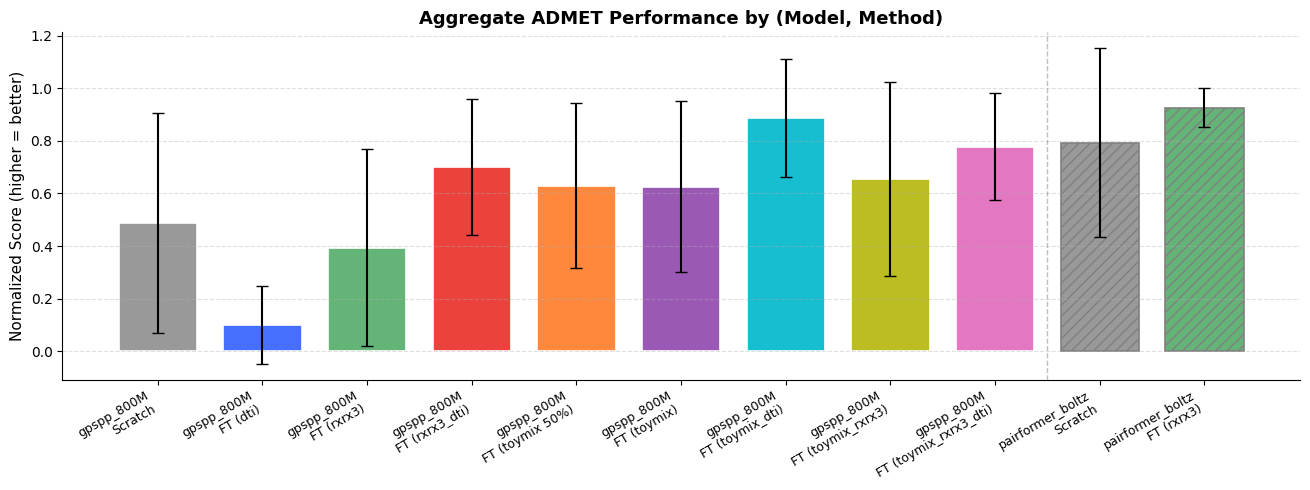

In [5]:
if len(admet_df) > 0 and admet_df['primary_metric'].notna().any():
    admet_df = admet_df.copy()

    # Create a combined label: "model / method"
    admet_df['model_method'] = admet_df['model_name'] + ' / ' + admet_df['method']

    # Normalize within each task: map metric to [0, 1] where 1 = best
    scores = []
    for task, group in admet_df.groupby('task'):
        direction = TASK_METRICS.get(task, (None, 'higher'))[1]
        vals = group['primary_metric'].astype(float)
        if direction == 'lower':
            vals = -vals
        vmin, vmax = vals.min(), vals.max()
        if vmax == vmin:
            norm = pd.Series(0.5, index=group.index)
        else:
            norm = (vals - vmin) / (vmax - vmin)
        scores.append(norm)
    admet_df['normalized_score'] = pd.concat(scores).astype(float)

    agg = admet_df.groupby(['model_name', 'method'])['normalized_score'].agg(['mean', 'std', 'count'])

    # Sort: by model order, then Scratch first, then FT alphabetically
    def sort_key(idx):
        model, method = idx
        model_order = MODELS_TO_SHOW.index(model) if model in MODELS_TO_SHOW else 999
        if method == 'Scratch':
            return (model_order, 0, method)
        return (model_order, 1, method)
    agg = agg.loc[sorted(agg.index, key=sort_key)]

    # Build display labels
    labels = [f'{m}\n{meth}' for m, meth in agg.index]

    # Color palette: same method gets same color regardless of model;
    # different models get different hatching
    method_colors = {'Scratch': '#999999'}
    ft_colors = ['#466eff', '#64B478', '#EB423D', '#FF883D', '#9B59B6',
                 '#17becf', '#bcbd22', '#e377c2']
    ft_idx = 0
    all_methods = sorted(admet_df['method'].unique())
    for m in all_methods:
        if m not in method_colors:
            method_colors[m] = ft_colors[ft_idx % len(ft_colors)]
            ft_idx += 1

    model_hatches = {m: h for m, h in zip(MODELS_TO_SHOW, ['', '///', '\\\\\\', 'xx', '..'])}

    fig, ax = plt.subplots(figsize=(max(10, len(agg) * 1.2), 5))
    x = np.arange(len(agg))
    for i, ((model, method), row) in enumerate(agg.iterrows()):
        color = method_colors.get(method, '#466eff')
        hatch = model_hatches.get(model, '')
        ax.bar(i, row['mean'], yerr=row['std'], color=color, hatch=hatch,
               edgecolor='white' if not hatch else 'grey',
               capsize=4, linewidth=1.2, width=0.75)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Normalized Score (higher = better)', fontsize=11)
    ax.set_title('Aggregate ADMET Performance by (Model, Method)', fontsize=13, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, axis='y', ls='--', alpha=0.4)

    # Add vertical separators between models
    prev_model = None
    for i, (model, _) in enumerate(agg.index):
        if prev_model is not None and model != prev_model:
            ax.axvline(x=i - 0.5, color='grey', linewidth=1, linestyle='--', alpha=0.5)
        prev_model = model

    plt.tight_layout()
    plt.show()
else:
    print("No ADMET results to aggregate.")

## 5. Per-task comparison: SOTA vs selected methods

5×6 grid where each row is an ADMET category (Absorption, Distribution, Metabolism, Excretion, Toxicity).
TDC SOTA shown as a thick black horizontal line with ±std shading. Our methods shown as colored bars.

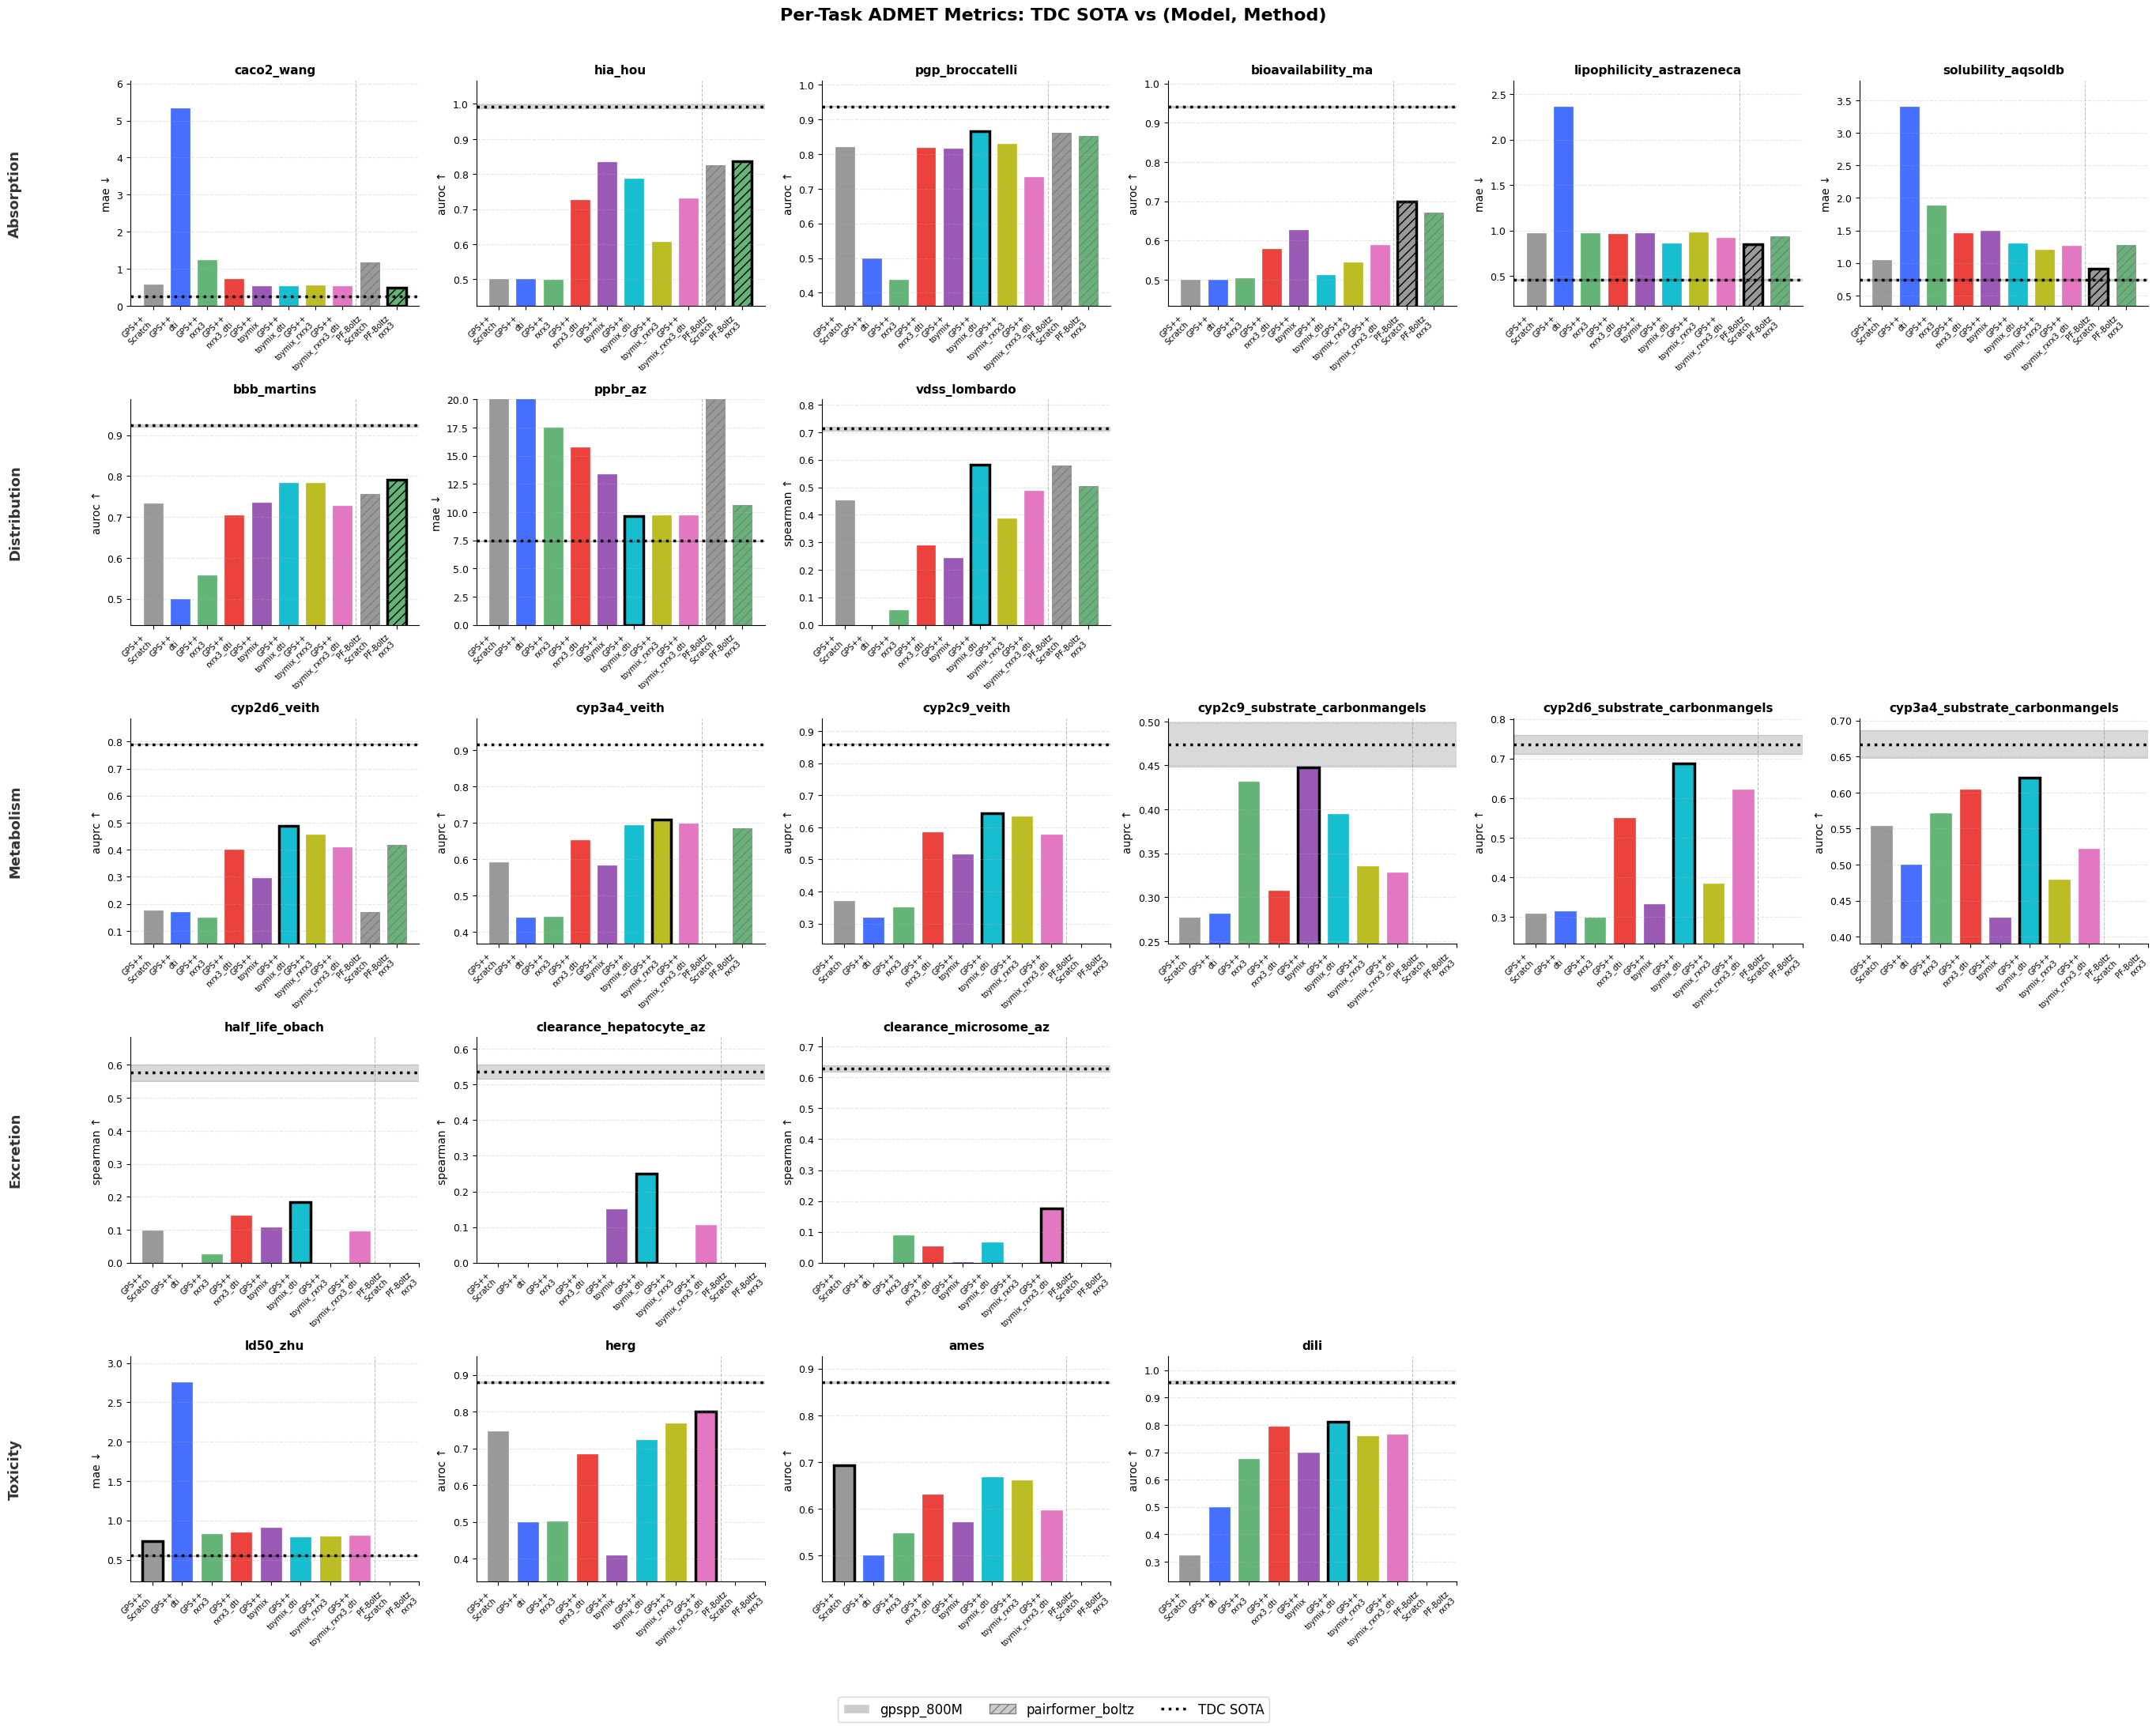


Pairs shown: 10
Models distinguished by hatching; same method = same color
TDC SOTA: dotted black horizontal line with ±std shading
Best across all (model, method): thick black border


In [6]:
# === Config: select which methods to compare alongside TDC SOTA ===
# Set to None to auto-include all available methods, or specify a list like:
SELECTED_METHODS = ['Scratch', 'FT (dti)', 'FT (rxrx3)', 'FT (rxrx3_dti)', 'FT (toymix)', 'FT (toymix_dti)', 'FT (toymix_rxrx3)', 'FT (toymix_rxrx3_dti)']
# SELECTED_METHODS = None

# Per-task y-axis overrides: {task: (ymin, ymax)} — set either to None to auto-compute
TASK_YLIM_OVERRIDES = {
    'ppbr_az': (None, 20),
}

from matplotlib.patches import Patch
from matplotlib.lines import Line2D

if len(admet_df) > 0 and admet_df['primary_metric'].notna().any():
    # Group by (task, model_name, method)
    task_model_method_means = admet_df.groupby(['task', 'model_name', 'method'])['primary_metric'].mean()

    # Build the list of (model, method) pairs to plot
    all_available = sorted(admet_df[['model_name', 'method']].drop_duplicates().apply(tuple, axis=1))
    if SELECTED_METHODS is None:
        pairs_to_plot = [(m, meth) for m, meth in all_available]
    else:
        pairs_to_plot = [(m, meth) for m, meth in all_available if meth in SELECTED_METHODS]

    # Sort: by model order, Scratch first within each model
    def pair_sort_key(pair):
        model, method = pair
        model_order = MODELS_TO_SHOW.index(model) if model in MODELS_TO_SHOW else 999
        if method == 'Scratch':
            return (model_order, 0, method)
        return (model_order, 1, method)
    pairs_to_plot = sorted(pairs_to_plot, key=pair_sort_key)

    # Short labels for x-axis: "model\nmethod"
    short_labels = []
    for model, method in pairs_to_plot:
        m_short = model.replace('gpspp_800M', 'GPS++').replace('pairformer_boltz', 'PF-Boltz')
        meth_short = method.replace('FT (', '').replace(')', '') if method.startswith('FT') else method
        short_labels.append(f'{m_short}\n{meth_short}')

    n_bars = len(pairs_to_plot)

    # Color palette: same method = same color; model distinguished by hatch
    method_colors = {'Scratch': '#999999'}
    ft_palette = ['#466eff', '#64B478', '#EB423D', '#FF883D', '#9B59B6',
                  '#17becf', '#bcbd22', '#e377c2']
    ft_idx = 0
    all_methods_sorted = sorted(admet_df['method'].unique())
    for m in all_methods_sorted:
        if m not in method_colors:
            method_colors[m] = ft_palette[ft_idx % len(ft_palette)]
            ft_idx += 1

    model_hatches = {m: h for m, h in zip(MODELS_TO_SHOW, ['', '///', '\\\\\\', 'xx', '..'])}
    colors = [method_colors.get(meth, '#466eff') for _, meth in pairs_to_plot]
    hatches = [model_hatches.get(model, '') for model, _ in pairs_to_plot]

    # Layout: 5 rows (one per ADMET category) × 6 cols
    CATEGORIES_ORDER = ['Absorption', 'Distribution', 'Metabolism', 'Excretion', 'Toxicity']
    CATEGORY_TASKS = {cat: [t for t in ADMET_TASK_ORDER if TASK_CATEGORY[t] == cat]
                      for cat in CATEGORIES_ORDER}

    fig, axes = plt.subplots(5, 6, figsize=(max(28, n_bars * 1.5), 22))
    x_pos = np.arange(n_bars)

    for row_idx, cat in enumerate(CATEGORIES_ORDER):
        tasks_in_cat = CATEGORY_TASKS[cat]
        for col_idx in range(6):
            ax = axes[row_idx, col_idx]

            if col_idx >= len(tasks_in_cat):
                ax.set_visible(False)
                continue

            task = tasks_in_cat[col_idx]
            metric_name, direction = TASK_METRICS[task]
            arrow = '\u2191' if direction == 'higher' else '\u2193'

            # Collect values for each (model, method) pair
            vals = []
            for model, method in pairs_to_plot:
                try:
                    vals.append(task_model_method_means.loc[(task, model, method)])
                except KeyError:
                    vals.append(np.nan)
            vals = np.array(vals, dtype=float)

            sota_mean = None
            if task in TDC_SOTA:
                sota_mean = TDC_SOTA[task][0]

            # Find best among all pairs
            finite_mask = np.isfinite(vals)
            best_idx = None
            if any(finite_mask):
                if direction == 'lower':
                    best_idx = np.where(finite_mask, vals, np.inf).argmin()
                else:
                    best_idx = np.where(finite_mask, vals, -np.inf).argmax()

            # Plot bars
            for i, (v, c, h) in enumerate(zip(vals, colors, hatches)):
                if np.isfinite(v):
                    if i == best_idx:
                        ax.bar(i, v, color=c, hatch=h, edgecolor='black', linewidth=2.5, width=0.7)
                    else:
                        ec = 'grey' if h else c
                        ax.bar(i, v, color=c, hatch=h, edgecolor=ec, linewidth=0.5, width=0.7)

            # SOTA as dotted black horizontal line with ±std shading
            if sota_mean is not None:
                _, sota_std, sota_method = TDC_SOTA[task]
                ax.axhline(y=sota_mean, color='black', linewidth=2.5, linestyle=':', zorder=5)
                ax.axhspan(sota_mean - sota_std, sota_mean + sota_std,
                           alpha=0.15, color='black', zorder=1)

            # Adjust y-axis limits
            all_finite = vals[np.isfinite(vals)].tolist()
            if sota_mean is not None:
                all_finite.append(sota_mean)
            if len(all_finite) >= 1:
                vmin, vmax = min(all_finite), max(all_finite)
                span = vmax - vmin if vmax > vmin else vmax * 0.1
                padding = span * 0.15
                ylo = max(0, vmin - padding)
                yhi = vmax + padding
                if task in TASK_YLIM_OVERRIDES:
                    override_lo, override_hi = TASK_YLIM_OVERRIDES[task]
                    if override_lo is not None:
                        ylo = override_lo
                    if override_hi is not None:
                        yhi = override_hi
                ax.set_ylim(ylo, yhi)

            ax.set_xticks(x_pos)
            ax.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=7)
            ax.set_title(f'{task}', fontsize=11, fontweight='bold')
            ax.set_ylabel(f'{metric_name} {arrow}', fontsize=10)
            ax.tick_params(axis='y', labelsize=9)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.grid(True, axis='y', ls='--', alpha=0.3)

            # Vertical separator between models
            prev_model = None
            for i, (model, _) in enumerate(pairs_to_plot):
                if prev_model is not None and model != prev_model:
                    ax.axvline(x=i - 0.5, color='grey', linewidth=0.8, linestyle='--', alpha=0.5)
                prev_model = model

            if col_idx == 0:
                ax.annotate(cat, xy=(-0.4, 0.5), xycoords='axes fraction',
                            fontsize=13, fontweight='bold', color='#333',
                            ha='center', va='center', rotation=90)

    # Legend: model hatching + SOTA line
    legend_handles = []
    for model in MODELS_TO_SHOW:
        h = model_hatches.get(model, '')
        legend_handles.append(Patch(facecolor='#cccccc', hatch=h,
                                    edgecolor='grey' if h else 'white', label=model))
    legend_handles.append(Line2D([0], [0], color='black', linewidth=2.5,
                                 linestyle=':', label='TDC SOTA'))
    fig.legend(handles=legend_handles, loc='lower center',
               ncol=min(len(legend_handles), 8), fontsize=12,
               bbox_to_anchor=(0.5, -0.01), frameon=True)

    fig.suptitle('Per-Task ADMET Metrics: TDC SOTA vs (Model, Method)',
                 fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0.03, 0.03, 1, 0.97])
    plt.show()

    print(f"\nPairs shown: {len(pairs_to_plot)}")
    print("Models distinguished by hatching; same method = same color")
    print("TDC SOTA: dotted black horizontal line with \u00b1std shading")
    print("Best across all (model, method): thick black border")
else:
    print("No ADMET results to plot.")